In [1]:
# ==========================================
# Imports
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from scipy.linalg import cho_factor, cho_solve
from tqdm import tqdm
from mnist_basis import BinaryBasisExtractor , get_neighbor_pairs
from anova_module import batch_shapley_values

In [2]:
# ==========================================
# MLP (Multilayer Perceptron)
# ==========================================

# Data Transformation Pipeline:
# 1. Convert to Tensor (values normalized to range [0.0, 1.0])
# 2. Binarization: Map pixel > 0.5 to 1.0, otherwise 0.0
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()) 
])

# Download and load training and testing datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoaders initialization
BATCH_SIZE = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

# Visual verification (Optional: inspect samples of binarized MNIST)
def show_sample():
    data_iter = iter(train_loader)
    images, labels = next(data_iter)
    img = images[0].squeeze()
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {labels[0]} - Pixel Values: {torch.unique(img)}")
    plt.show()

# Uncomment the line below to visualize a binarized sample
# show_sample()

# --- 2. Model Definition (Simple MLP) ---

class BinarizedMNIST_MLP(nn.Module):
    def __init__(self):
        super(BinarizedMNIST_MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.model = nn.Sequential(
            nn.Linear(28 * 28, 512),   # Input layer: 784 flattened pixels
            nn.ReLU(),                 # Non-linear activation
            nn.Dropout(0.2),           # Dropout for regularization
            nn.Linear(512, 128),       # Hidden layer
            nn.ReLU(),
            nn.Linear(128, 10)         # Output layer: 10 classes (digits 0-9)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.model(x)
        return logits

# Model instantiation (defaulting to CPU)
device = torch.device("cpu")
model = BinarizedMNIST_MLP().to(device)

# --- 3. Training Phase ---

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 3  # 3 epochs are sufficient for MNIST on CPU

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        # Reset gradients
        optimizer.zero_grad()
        
        # Forward pass
        output = model(data)
        loss = criterion(output, target)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if batch_idx % 300 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

# --- 4. Evaluation and Performance ---

print("\nModel Evaluation...")
model.eval()
all_preds = []
all_targets = []
correct = 0

with torch.no_grad(): # Disable gradient computation for evaluation (efficiency)
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        
        # Retrieve the class with the highest probability (Argmax)
        pred = output.argmax(dim=1, keepdim=True) 
        
        # Compute raw accuracy
        correct += pred.eq(target.view_as(pred)).sum().item()
        
        # Store predictions for detailed sklearn report
        all_preds.extend(pred.flatten().cpu().numpy())
        all_targets.extend(target.cpu().numpy())

accuracy = 100. * correct / len(test_loader.dataset)

print("--------------------------------------------------")
print(f"Global Accuracy: {accuracy:.2f}%")
print("--------------------------------------------------")
print("\n Detailed Classification Report:\n")
print(classification_report(all_targets, all_preds, digits=4))

Epoch 1/3 | Batch 0/938 | Loss: 2.3089
Epoch 1/3 | Batch 300/938 | Loss: 0.1230
Epoch 1/3 | Batch 600/938 | Loss: 0.1508
Epoch 1/3 | Batch 900/938 | Loss: 0.1500
Epoch 2/3 | Batch 0/938 | Loss: 0.0435
Epoch 2/3 | Batch 300/938 | Loss: 0.0569
Epoch 2/3 | Batch 600/938 | Loss: 0.1208
Epoch 2/3 | Batch 900/938 | Loss: 0.3484
Epoch 3/3 | Batch 0/938 | Loss: 0.0363
Epoch 3/3 | Batch 300/938 | Loss: 0.1474
Epoch 3/3 | Batch 600/938 | Loss: 0.0617
Epoch 3/3 | Batch 900/938 | Loss: 0.1037

Model Evaluation...
--------------------------------------------------
Global Accuracy: 97.09%
--------------------------------------------------

 Detailed Classification Report:

              precision    recall  f1-score   support

           0     0.9857    0.9867    0.9862       980
           1     0.9775    0.9938    0.9856      1135
           2     0.9550    0.9864    0.9704      1032
           3     0.9438    0.9812    0.9621      1010
           4     0.9697    0.9786    0.9742       982
       

In [3]:
# ==========================================
# Context
# ==========================================

# Dataset
full_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)

all_images_tensor, _ = next(iter(full_loader))

X_encoded_tensor = all_images_tensor.view(all_images_tensor.size(0), -1)

X_encoded = X_encoded_tensor.numpy() # array numpy of {0,1}^{ 60 000 x 784 }

n , d = X_encoded.shape

# Function of interest
def predict_array(i , X_numpy):
    model.eval() 
    
    with torch.no_grad(): 
        
        X_tensor = torch.from_numpy(X_numpy).float().to(device)
        
        logits = model(X_tensor)
        
        probas = torch.softmax(logits, dim=1)
        
        return probas[: , i].cpu().numpy()

In [4]:
%%time

# ==========================================
# Functional ANOVA Framework
# ==========================================

A_neighbors = get_neighbor_pairs(28)
B = BinaryBasisExtractor(X_encoded, A=A_neighbors, n_set=2000, rtol=1e-3, atol=1e-3, maxpool=200, verbose=True)

X_uniq = B.get_patterns() # Support \mathcal{X}
S = B.get_sets() # Selected Sets
P = B.get_P() # Array of probabilities
M = B.get_matrix() # Basis matrix (low rank)

Gamma = (M.T * P) @ M # Gamma matrix

y_tot = predict_array(3 , X_uniq) # We focus on predicting class 3

var = y_tot ** 2 @ P - (y_tot @ P)**2 # variance

mu = (M.T * P) @ y_tot # mu vector
Gamma[np.diag_indices_from(Gamma)] += 1e-10 # Regularization of Gamma for lower condition number
    
c, low = cho_factor(Gamma, lower=True) # LLT Resolution
coeff = cho_solve((c, low), mu) # fourier coefficient

Matrix = M * coeff # Anova Matrix

# ====================================================================================================================================

# XAI Metrics

Main_effects = batch_shapley_values(d , S[:674] , Matrix[: , :674]) 
Anova_Shap = batch_shapley_values(d , S , Matrix)

# ====================================================================================================================================

# Errors

Err_L2 = ((np.sum(Matrix , axis = 1) - y_tot)**2) @ P # Error L2
Err_L2_rel = Err_L2 / ( y_tot**2 @ P ) # Error L2 Relative
R_2 = 1 - (Err_L2) /(var) #R squared

# ====================================================================================================================================
# Display performance metrics
print("-" * 30)
print(f"R² (Coeff. of determination) : {R_2:.4f}")      # 4 decimal places
print(f"L2 Error                     : {Err_L2:.4e}")  # Scientific notation (e.g., 1.2345e-04)
print(f"Relative L2 Error            : {Err_L2_rel:.2%}") # Percentage format (e.g., 5.43%)
print(f"Rank of Matrix M             : {np.linalg.matrix_rank(M)}") # uncomment to verify rank but increases computation time
print("-" * 30)

Accepted sets: 100%|██████████| 2000/2000 [00:55<00:00, 36.11it/s]


------------------------------
R² (Coeff. of determination) : 0.7281
L2 Error                     : 2.4372e-02
Relative L2 Error            : 24.14%
Rank of Matrix M             : 2000
------------------------------
CPU times: user 3min 56s, sys: 3.53 s, total: 3min 59s
Wall time: 1min 7s


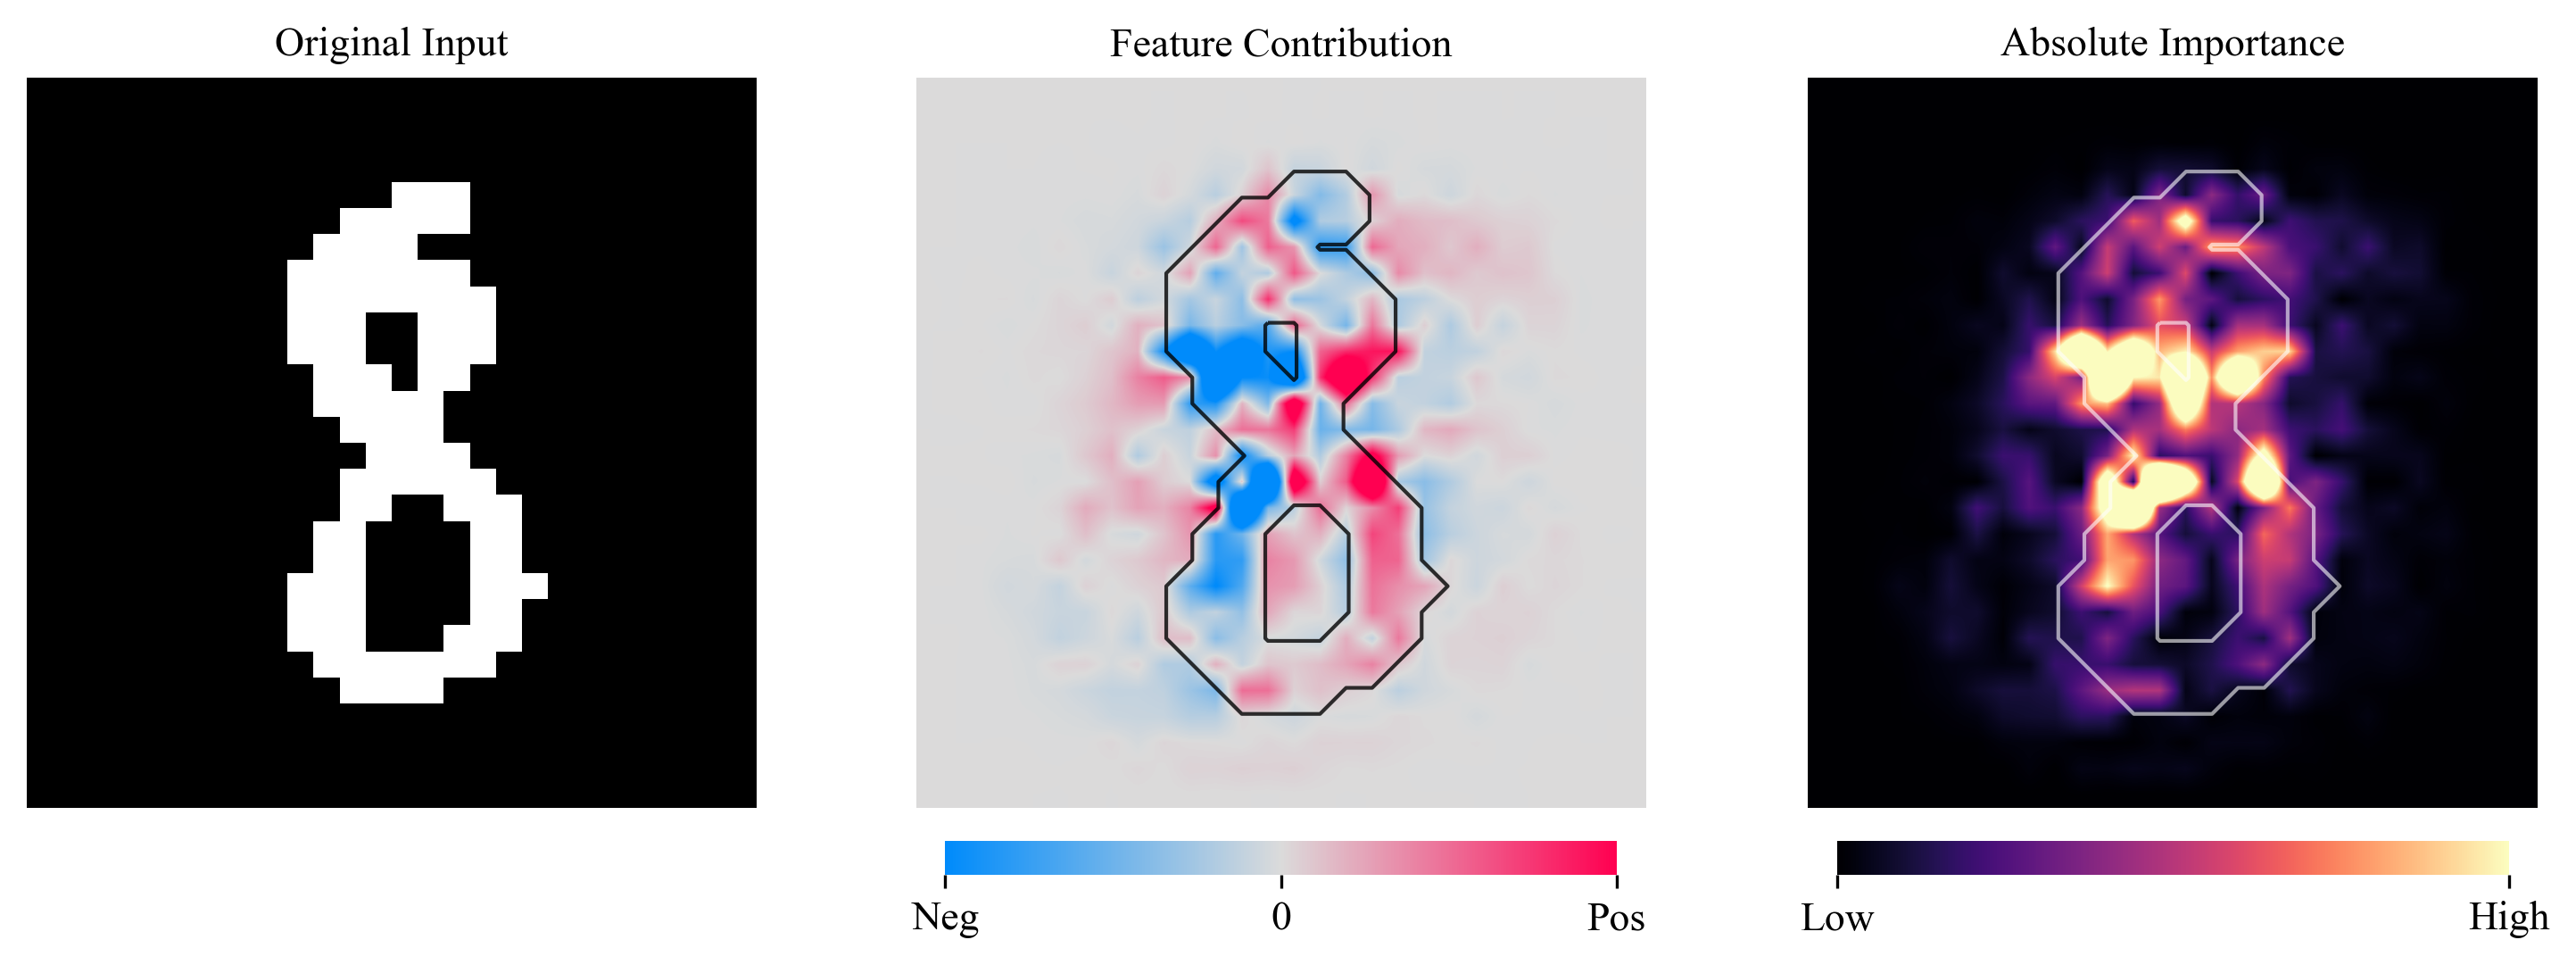

In [5]:
# ==========================================
# Plots
# ==========================================

explainer = Anova_Shap
sample_idx = 44162 

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 11,
    "axes.titlesize": 11,
    "figure.dpi": 300,
    "savefig.bbox": "tight",
})

flat_vector = X_uniq[sample_idx, :]
original_image = flat_vector.reshape(28, 28)
predicted_class = y_tot[sample_idx]

shap_vector = explainer[sample_idx, :]
shap_image = shap_vector.reshape(28, 28)

colors = ["#008bfb", "#dbdbdb", "#ff0051"]
shap_cmap = mcolors.LinearSegmentedColormap.from_list("shap_style", colors)

abs_vals = np.abs(shap_image)
max_val = np.percentile(abs_vals, 98)
if max_val < 1e-9: 
    max_val = np.max(abs_vals) if np.max(abs_vals) > 1e-9 else 0.1

contour_threshold = 0.1 * np.max(original_image)
if contour_threshold < 0.001: contour_threshold = 0.1

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), constrained_layout=True)

axes[0].imshow(original_image, cmap='gray', interpolation='nearest')
axes[0].set_title("Original Input")
axes[0].axis('off')

heatmap_shap = axes[1].imshow(shap_image,
                              cmap=shap_cmap,
                              interpolation='bilinear',
                              vmin=-max_val, 
                              vmax=max_val)


axes[1].contour(original_image, 
                levels=[contour_threshold], 
                colors='black', 
                linestyles='solid', 
                linewidths=1.0,
                alpha=0.8)

axes[1].set_title("Feature Contribution")
axes[1].axis('off')

cbar1 = fig.colorbar(heatmap_shap, ax=axes[1], orientation='horizontal', fraction=0.046, pad=0.04)
cbar1.outline.set_visible(False)
cbar1.set_ticks([-max_val, 0, max_val]) 
cbar1.set_ticklabels(['Neg', '0', 'Pos']) 

heatmap_magma = axes[2].imshow(abs_vals, 
                               cmap='magma',
                               interpolation='bilinear',
                               vmin=0, 
                               vmax=max_val)

axes[2].contour(original_image, 
                levels=[contour_threshold], 
                colors='white', 
                linestyles='solid', 
                linewidths=1.0,
                alpha=0.6)

axes[2].set_title("Absolute Importance")
axes[2].axis('off')

cbar2 = fig.colorbar(heatmap_magma, ax=axes[2], orientation='horizontal', fraction=0.046, pad=0.04)
cbar2.outline.set_visible(False)
cbar2.set_ticks([0, max_val])
cbar2.set_ticklabels(['Low', 'High'])

# plt.savefig(f"analysis_idx_{sample_idx}.pdf", format='pdf')

plt.show()